In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("real_estate_consumer_data.csv")
print(df)
df.head()

    PropertyID  Latitude  Longitude     Price  Area_sqft  Bedrooms  \
0            1   13.0827    80.2707   4500000       1200         2   
1            2   13.0400    80.2500   6200000       1500         3   
2            3   13.1000    80.2800   3900000       1000         2   
3            4   13.1500    80.3000   8700000       2100         4   
4            5   13.0600    80.2200   5200000       1400         3   
5            6   13.1200    80.3100   9400000       2500         4   
6            7   13.0300    80.2400   4100000       1100         2   
7            8   13.0900    80.2600   5800000       1600         3   
8            9   13.1800    80.3300   9800000       2600         4   
9           10   13.1100    80.2900   7600000       1900         3   
10          11   13.0500    80.2300   4700000       1250         2   
11          12   13.1400    80.3200   9200000       2400         4   
12          13   13.0200    80.2100   3800000        950         2   
13          14   13.

,PropertyID,Latitude,Longitude,Price,Area_sqft,Bedrooms,ConsumerIncome
0,1,13.0827,80.2707,4500000,1200,2,55000
1,2,13.0400,80.2500,6200000,1500,3,70000
2,3,13.1000,80.2800,3900000,1000,2,48000
3,4,13.1500,80.3000,8700000,2100,4,120000
4,5,13.0600,80.2200,5200000,1400,3,65000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PropertyID      20 non-null     int64  
 1   Latitude        20 non-null     float64
 2   Longitude       20 non-null     float64
 3   Price           20 non-null     int64  
 4   Area_sqft       20 non-null     int64  
 5   Bedrooms        20 non-null     int64  
 6   ConsumerIncome  20 non-null     int64  
dtypes: float64(2), int64(5)
memory usage: 1.2 KB


In [4]:
X = df[['Latitude',
        'Longitude',
        'Price',
        'Area_sqft',
        'Bedrooms',
        'ConsumerIncome']]

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

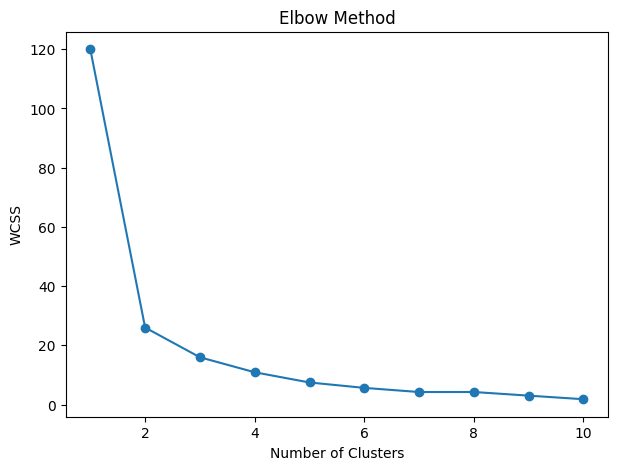

In [7]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

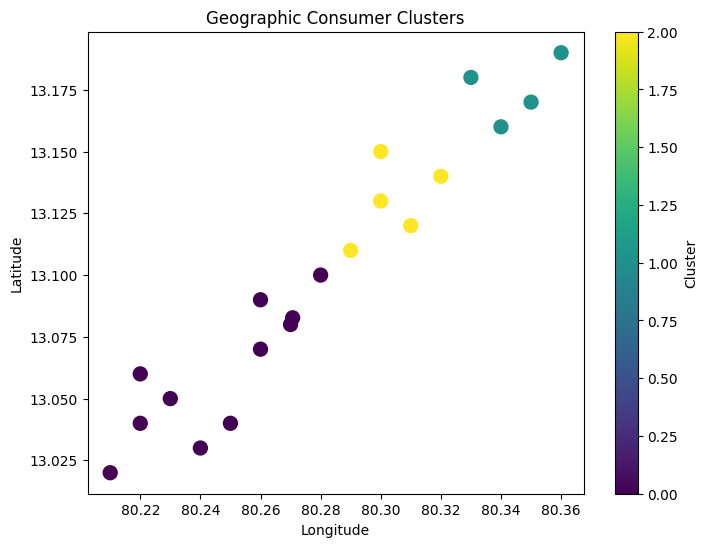

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(df['Longitude'],
            df['Latitude'],
            c=df['Cluster'],
            cmap='viridis',
            s=100)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Consumer Clusters")

plt.colorbar(label="Cluster")

plt.show()